In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path("..").resolve()  
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)
DATA_PROCESSED = ROOT / "reports" / "metrics"
print("processed exists:", DATA_PROCESSED.exists(), DATA_PROCESSED)


ROOT: C:\Users\javie\Documents\b\undac-thesis-smart-math-tutor
processed exists: True C:\Users\javie\Documents\b\undac-thesis-smart-math-tutor\reports\metrics


In [4]:
kdd_files = sorted(DATA_PROCESSED.glob("*.csv"))
[(p.name, p.stat().st_size // (1024*1024)) for p in kdd_files]  # (nombre, MB)

[('model_leaderboard.csv', 0), ('processed_dataset.csv', 57)]

In [8]:
# Elige 1 archivo (master suele ser grande)
path = next(iter(sorted(DATA_PROCESSED.glob("processed_*.csv"))), None) or next(iter(sorted(DATA_PROCESSED.glob("*.csv"))), None)
assert path is not None, "No encontré archivos .csv en reports/metrics"

print("Leyendo:", path.name)

# nrows para explorar rápido
raw_kdd = pd.read_csv(path, sep=",", low_memory=False, nrows=50_0000)
raw_kdd.head(3)


Leyendo: processed_dataset.csv


,student_id,step_name,incorrects,hints,correct_first_attempt,step_duration_sec,source_split,timestamp,event_order,effort_score,...,student_avg_incorrects_prev,student_avg_time_prev,student_accuracy_prev,student_trend_accuracy,step_len,step_num_ops,step_has_parentheses,step_num_digits,step_num_variables,step_abs_constant_sum
0,0BrbPbwCMz,b+r*(x+y) = v-s,0.0,0.0,0,0.0,test,NaN,299585,0.15,...,0.335159,22.209422,0.795723,0.795723,15.0,5.0,1.0,0.0,6.0,0.0
1,0BrbPbwCMz,m*(k-n) = g*s,0.0,0.0,0,0.0,test,NaN,299586,0.15,...,0.000000,0.000000,0.000000,0.000000,13.0,4.0,1.0,0.0,5.0,0.0
2,2oNLCndtam,-9.91y-6.3 = -2.13,0.0,0.0,0,0.0,test,NaN,299587,0.15,...,0.335159,22.209422,0.795723,0.795723,18.0,4.0,0.0,8.0,1.0,124.0


In [9]:
raw_kdd["effort_score"]

0         0.150000
1         0.150000
2         0.150000
3         0.150000
4         0.150000
            ...   
301022    0.001666
301023    0.001666
301024    0.001363
301025    0.001212
301026    0.001060
Name: effort_score, Length: 301027, dtype: float64

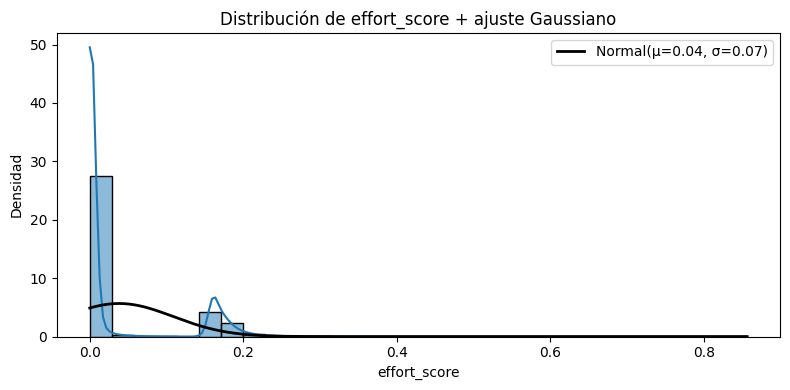

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Serie numérica (sin NaN)
s = pd.to_numeric(raw_kdd["effort_score"], errors="coerce").dropna()

mu = float(s.mean())
sigma = float(s.std(ddof=0))

plt.figure(figsize=(8, 4))
sns.histplot(s, bins=30, stat="density", kde=True, color="#1f77b4")

# Curva Gaussiana ajustada (Normal)
if sigma > 0:
    x = np.linspace(float(s.min()), float(s.max()), 400)
    pdf = (1.0 / (sigma * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    plt.plot(x, pdf, color="black", linewidth=2, label=f"Normal(μ={mu:.2f}, σ={sigma:.2f})")
    plt.legend()

plt.title("Distribución de effort_score + ajuste Gaussiano")
plt.xlabel("effort_score")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()
